# 04 — Satellite Coverage & Weather-Adaptive Routing: ASEAN

Phân tích coverage Starlink LEO và routing thích ứng thời tiết cho vùng ASEAN.

## Nội dung
1. Load TLE data (Starlink)
2. Coverage map tại một thời điểm
3. Elevation time series — Hanoi
4. Pass windows analysis
5. SKR time series: greedy vs baseline
6. Routing improvement: wet vs dry season
7. Multi-city routing comparison

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, timedelta, timezone

from skyfield.api import load, wgs84

from modules.orbital_mechanics import (
    parse_tle_block, make_skyfield_satellite,
    get_visible_satellites, make_time_array,
    compute_elevation_timeseries, find_pass_windows,
    compute_coverage_grid, GROUND_STATIONS,
    fetch_tle_celestrak,
)
from modules.routing import (
    compute_skr_timeseries, compute_routing_improvement,
    compute_daily_key_bits,
)
from modules.weather_model import get_city_params

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.5,
})

_TS = load.timescale()

# Reference time: 2026-03-12 12:00 UTC
T_REF = datetime(2026, 3, 12, 12, 0, 0, tzinfo=timezone.utc)
MIN_ELEV = 10.0   # routing threshold (degrees)

# --- Helper: Draw Hoang Sa / Truong Sa on plain matplotlib axes ---
# Island coordinates from Wikipedia/CIA World Factbook (public domain)
_HOANG_SA_COORDS = [  # (lon, lat) of major features
    (112.3333, 16.8333),  # Woody Island
    (112.7333, 16.6667),  # Lincoln Island
    (111.2000, 15.7833),  # Triton Island
    (111.7667, 16.4667),  # Drummond Island
    (111.6000, 16.5333),  # Pattle Island
    (111.6667, 16.2500),  # Discovery Reef
    (112.5333, 16.0333),  # Bombay Reef
    (111.5167, 17.0833),  # North Reef
    (112.2667, 16.9667),  # Tree Island
]
_TRUONG_SA_COORDS = [  # (lon, lat) of Vietnam-claimed features
    (111.9167, 8.6333),   # Spratly Island
    (114.3333, 11.4333),  # Southwest Cay
    (114.3667, 10.1833),  # Namyit Island
    (114.3333, 9.8833),   # Sin Cowe Island
    (114.4833, 10.3833),  # Sand Cay
    (112.9167, 7.8833),   # Amboyna Cay
    (113.3167, 8.1500),   # Barque Canada Reef
    (113.6833, 8.9500),   # Pearson Reef
    (114.6500, 8.8500),   # Tennent Reef
    (114.2000, 8.7167),   # Cornwallis South Reef
]

def draw_vietnam_islands(ax, use_cartopy=False):
    """Draw Hoang Sa and Truong Sa using actual island positions + convex hull."""
    from scipy.spatial import ConvexHull
    kwargs = {}
    if use_cartopy:
        import cartopy.crs as ccrs
        kwargs = {'transform': ccrs.PlateCarree()}
    for coords, label, offset in [
        (_HOANG_SA_COORDS, 'Qu\u1ea7n \u0111\u1ea3o\nHo\u00e0ng Sa', (0.3, 0.3)),
        (_TRUONG_SA_COORDS, 'Qu\u1ea7n \u0111\u1ea3o\nTr\u01b0\u1eddng Sa', (0.3, 0.3)),
    ]:
        pts = np.array(coords)
        lons, lats = pts[:, 0], pts[:, 1]
        ax.scatter(lons, lats, s=8, color='#c00000', marker='^', zorder=6,
                   linewidths=0.3, edgecolors='darkred', **kwargs)
        hull = ConvexHull(pts)
        hull_pts = pts[hull.vertices]
        hull_pts = np.vstack([hull_pts, hull_pts[0]])
        ax.plot(hull_pts[:, 0], hull_pts[:, 1], color='#c00000',
                linewidth=1.0, linestyle='--', zorder=5, **kwargs)
        cx, cy = lons.mean(), lats.mean()
        ax.text(cx + offset[0], cy + offset[1], label,
                fontsize=5.5, color='#c00000', ha='center', va='center',
                fontweight='bold', zorder=7, **kwargs)

print('Modules loaded OK')


Modules loaded OK


## 1. Load TLE Data

Dùng TLE mẫu (synthetic) để demo. Trong thực tế, tải từ CelesTrak:
```python
from modules.orbital_mechanics import fetch_tle_celestrak
tle_dicts = fetch_tle_celestrak('starlink')
```

In [2]:
# Synthetic Starlink constellation — 8 planes × 22 satellites = 176 total
# Matching Starlink shell 1: 53° inclination, 550 km, 15.05 rev/day
print('Attempting CelesTrak download...')
use_real_tle = False
try:
    tle_dicts_real = fetch_tle_celestrak('starlink', timeout=15)
    if len(tle_dicts_real) > 100:
        tle_dicts = tle_dicts_real
        use_real_tle = True
        print(f'Downloaded {len(tle_dicts)} real Starlink TLEs')
    else:
        raise ValueError('Too few satellites')
except Exception as e:
    print(f'CelesTrak unavailable ({e}). Using synthetic constellation.')

if not use_real_tle:
    INC, N_REV, EPOCH = 53.0, 15.05, '26071.50000000'
    N_PLANES, N_PER_PLANE = 8, 22
    PLANE_LABELS = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII']
    GROUP_MAP = {0:'I', 1:'I', 2:'II', 3:'II', 4:'III', 5:'III', 6:'IV', 7:'IV'}

    lines = []
    sat_num = 44235
    for p_idx in range(N_PLANES):
        raan = p_idx * (360.0 / N_PLANES)
        for k in range(N_PER_PLANE):
            M0 = k * (360.0 / N_PER_PLANE)
            grp = GROUP_MAP[p_idx]
            name = f'SL-{grp}-{PLANE_LABELS[p_idx]}{k+1:02d}'
            l1 = (f'1 {sat_num:05d}U 19029X   {EPOCH}  .00001000  '
                  f'00000-0  10000-3 0  999{k%10}')
            l2 = (f'2 {sat_num:05d} {INC:8.4f} {raan:8.4f} 0001000 '
                  f' 90.0000 {M0:8.4f} {N_REV:.8f} 0000{k%10}')
            lines.append(name); lines.append(l1); lines.append(l2)
            sat_num += 1

    tle_dicts = parse_tle_block('\n'.join(lines))
    print(f'Generated {len(tle_dicts)} synthetic satellites '
          f'({N_PLANES} planes × {N_PER_PLANE} sats)')

satellites = [make_skyfield_satellite(d) for d in tle_dicts]

def get_group(name):
    """Extract orbital group from satellite name."""
    if name.startswith('SL-'):
        parts = name.split('-')
        return parts[1] if len(parts) >= 2 else 'X'
    return 'X'

sat_groups = {d['name']: get_group(d['name']) for d in tle_dicts}

print(f'Loaded {len(satellites)} satellites')
for g in ['I', 'II', 'III', 'IV']:
    n = sum(1 for v in sat_groups.values() if v == g)
    print(f'  Group {g}: {n} satellites')

Attempting CelesTrak download...


CelesTrak unavailable (CelesTrak returned HTTP 403 for group 'starlink'). Using synthetic constellation.
Generated 176 synthetic satellites (8 planes × 22 sats)
Loaded 176 satellites
  Group I: 44 satellites
  Group II: 44 satellites
  Group III: 44 satellites
  Group IV: 44 satellites


## 2. Elevation Time Series — Hanoi (24h)

Scanning 24h for best visibility window over Hanoi...


Best window: T+252min (16:12 UTC), max simultaneous visible: 4
Satellites visible in window: 74


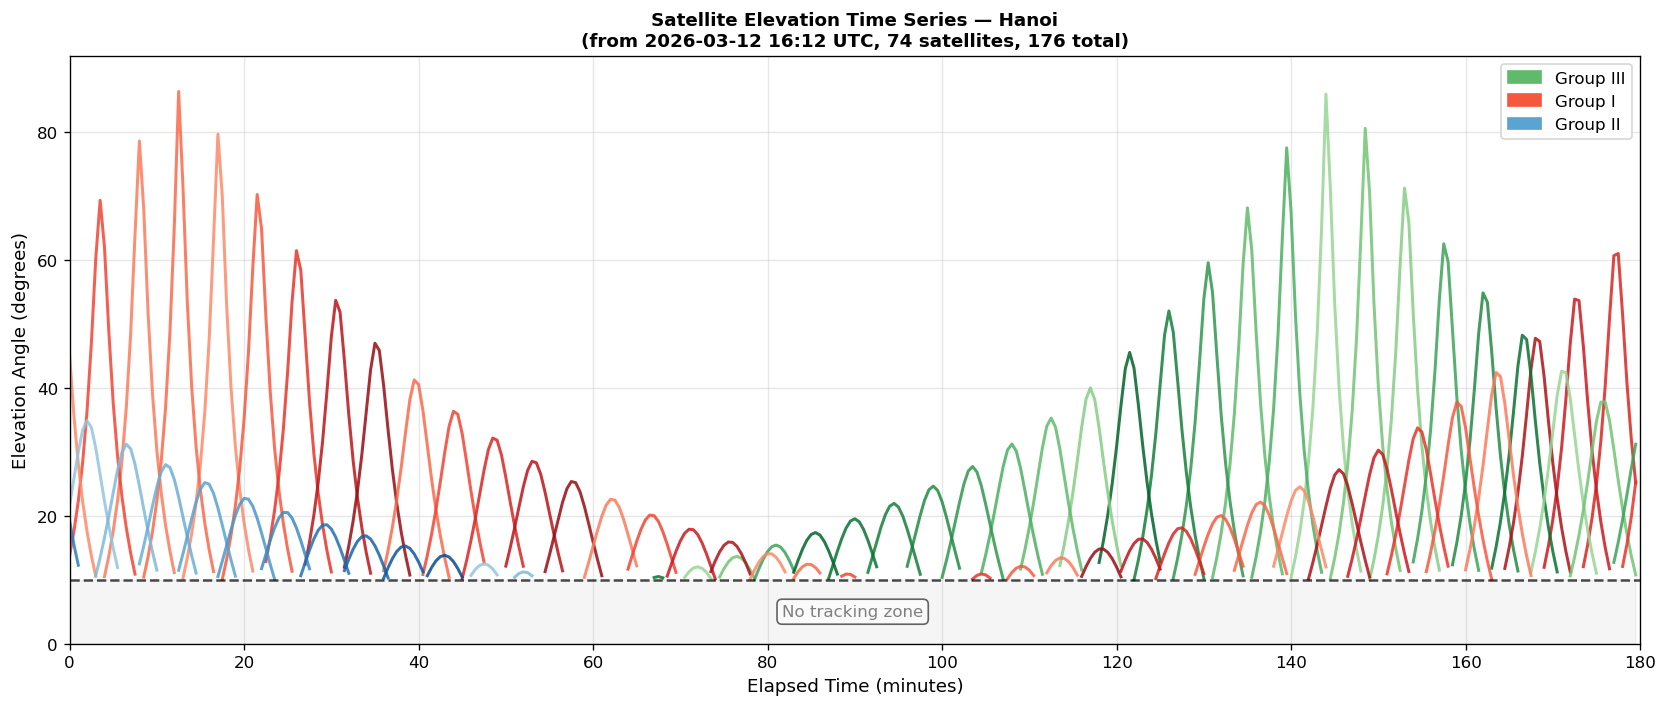

Groups visible: ['I', 'II', 'III']


In [3]:
gs = GROUND_STATIONS['hanoi']
obs_hanoi = wgs84.latlon(gs['lat'], gs['lon'], elevation_m=gs['alt_m'])

# --- Scan 24h to find best 3h window (most simultaneous visible satellites) ---
print('Scanning 24h for best visibility window over Hanoi...')
n_scan = 24 * 60
t_scan_list = [T_REF + timedelta(minutes=i) for i in range(n_scan)]
t_scan = _TS.from_datetimes(t_scan_list)

sat_elevs_24h = {}
visible_count = np.zeros(n_scan)
for sat in satellites:
    diff = sat - obs_hanoi
    topo = diff.at(t_scan)
    alt, _, _ = topo.altaz()
    elevs = np.array(alt.degrees)
    sat_elevs_24h[sat.name] = elevs
    visible_count += (elevs >= MIN_ELEV).astype(float)

# Best 3h window
WIN_MIN = 180
best_start = int(np.argmax(np.convolve(visible_count, np.ones(WIN_MIN), 'valid')))
T_WIN_START = T_REF + timedelta(minutes=best_start)
print(f'Best window: T+{best_start}min ({T_WIN_START.strftime("%H:%M UTC")}), '
      f'max simultaneous visible: {visible_count[best_start:best_start+WIN_MIN].max():.0f}')

# --- Fine-resolution elevation for the window (30s steps) ---
n_fine = WIN_MIN * 2  # 30s steps
t_fine_list = [T_WIN_START + timedelta(seconds=i*30) for i in range(n_fine)]
t_fine = _TS.from_datetimes(t_fine_list)
elapsed_min = np.arange(n_fine) * 0.5  # minutes

# Find satellites visible in this window
visible_in_window = []
for sat in satellites:
    elevs_win = sat_elevs_24h[sat.name][best_start:best_start+WIN_MIN]
    if elevs_win.max() >= MIN_ELEV:
        diff = sat - obs_hanoi
        topo = diff.at(t_fine)
        alt, _, _ = topo.altaz()
        visible_in_window.append({
            'sat': sat, 'name': sat.name,
            'group': sat_groups[sat.name],
            'elevs_fine': np.array(alt.degrees),
            'max_el': elevs_win.max(),
        })

visible_in_window.sort(key=lambda x: x['max_el'], reverse=True)
print(f'Satellites visible in window: {len(visible_in_window)}')

# --- Plot fig12 — Paper 1 style with group coloring ---
GROUP_COLORS = {
    'I':   {'color': '#d62728', 'label': 'Group I'},
    'II':  {'color': '#1f77b4', 'label': 'Group II'},
    'III': {'color': '#2ca02c', 'label': 'Group III'},
    'IV':  {'color': '#ff7f0e', 'label': 'Group IV'},
    'X':   {'color': '#9467bd', 'label': 'Starlink'},
}

group_counters = {g: 0 for g in GROUP_COLORS}
legend_handles = {}

fig, ax = plt.subplots(figsize=(7.16, 4.0))

for v in visible_in_window:
    grp = v['group'] if v['group'] in GROUP_COLORS else 'X'
    color = GROUP_COLORS[grp]['color']
    group_counters[grp] += 1

    elev_plot = np.where(v['elevs_fine'] >= MIN_ELEV, v['elevs_fine'], np.nan)
    ax.plot(elapsed_min, elev_plot, color=color, linewidth=1.2, alpha=0.75)

    if grp not in legend_handles:
        legend_handles[grp] = mpatches.Patch(
            color=color,
            label=GROUP_COLORS[grp]['label'],
        )

# No-tracking zone
ax.fill_between(elapsed_min, 0, MIN_ELEV, alpha=0.08, color='gray', zorder=0)
ax.axhline(MIN_ELEV, color='k', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(elapsed_min[-1] * 0.5, MIN_ELEV / 2, 'No tracking zone',
        ha='center', va='center', fontsize=8, color='gray',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))

ax.set_xlabel('Elapsed Time (minutes)', fontsize=9)
ax.set_ylabel('Elevation Angle (degrees)', fontsize=9)
ax.set_title(
    f'Satellite Elevation Time Series — Hanoi\n'
    f'(from {T_WIN_START.strftime("%Y-%m-%d %H:%M UTC")}, '
    f'{len(visible_in_window)} satellites, {len(satellites)} total)',
    fontsize=9, fontweight='bold',
)
ax.set_xlim(0, WIN_MIN)
ax.set_ylim(0, 92)
# Sort legend by group name for consistent ordering
sorted_handles = [legend_handles[g] for g in ['I', 'II', 'III', 'IV', 'X'] if g in legend_handles]
ax.legend(handles=sorted_handles, loc='upper right', fontsize=8)
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig12_elevation_timeseries_hanoi.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Groups visible: {sorted(set(v["group"] for v in visible_in_window))}')

## 3. Pass Windows Analysis

In [4]:
import pandas as pd

# Use the 24h scan array already computed in cell-5
# t_scan covers 24h with 1-min steps from T_REF
rows = []
for sat in satellites[:20]:  # show first 20 sats for readability
    windows = find_pass_windows(
        sat, gs['lat'], gs['lon'], t_scan, gs['alt_m'], min_elevation=MIN_ELEV
    )
    for w in windows:
        rows.append({
            'Satellite': sat.name,
            'Group': sat_groups[sat.name],
            'Start (h)': f"{w['start_idx']/60:.2f}",
            'End (h)':   f"{w['end_idx']/60:.2f}",
            'Duration (min)': w['duration_steps'],
            'Peak El (°)': f"{w['peak_elevation']:.1f}",
        })

df_passes = pd.DataFrame(rows)
print(f'Total passes (first 20 sats, 24h): {len(df_passes)}')
if len(df_passes) > 0:
    print(df_passes.head(30).to_string(index=False))

Total passes (first 20 sats, 24h): 66
Satellite Group Start (h) End (h)  Duration (min) Peak El (°)
 SL-I-I01     I      3.38    3.47               6        19.4
 SL-I-I01     I      5.03    5.13               7        28.5
 SL-I-I01     I     17.18   17.22               3        11.6
 SL-I-I01     I     18.80   18.92               8        43.1
 SL-I-I02     I      3.32    3.38               5        17.8
 SL-I-I02     I      4.95    5.07               8        31.8
 SL-I-I02     I     17.13   17.13               1        10.3
 SL-I-I02     I     18.73   18.85               8        49.3
 SL-I-I03     I      3.23    3.32               6        15.9
 SL-I-I03     I      4.88    4.98               7        36.4
 SL-I-I03     I     18.65   18.77               8        54.3
 SL-I-I04     I      3.17    3.23               5        14.6
 SL-I-I04     I      4.80    4.92               8        40.6
 SL-I-I04     I     18.58   18.70               8        64.0
 SL-I-I05     I      3.10    3.1

## 4. SKR Time Series: Greedy vs Baseline — Dry Season

In [5]:
# Dry season weather (January, Hanoi)
wx_dry = get_city_params('hanoi', 1)
wx_wet = get_city_params('hanoi', 7)

print(f"Dry (Jan): R={wx_dry['R_mm_h']:.4f} mm/h, V={wx_dry['V_km']} km, P_cloud={wx_dry['P_cloud']}")
print(f"Wet (Jul): R={wx_wet['R_mm_h']:.4f} mm/h, V={wx_wet['V_km']} km, P_cloud={wx_wet['P_cloud']}")

# Compute time series (6h)
ts_dry = compute_skr_timeseries(
    satellites=satellites,
    lat_deg=gs['lat'], lon_deg=gs['lon'],
    t_start=T_REF,
    R_mm_h=wx_dry['R_mm_h'], V_km=wx_dry['V_km'], P_cloud=wx_dry['P_cloud'],
    duration_hours=3.0, step_minutes=1.0, alt_m=gs['alt_m'],
    min_elevation=MIN_ELEV,
)

ts_wet = compute_skr_timeseries(
    satellites=satellites,
    lat_deg=gs['lat'], lon_deg=gs['lon'],
    t_start=T_REF,
    R_mm_h=wx_wet['R_mm_h'], V_km=wx_wet['V_km'], P_cloud=wx_wet['P_cloud'],
    duration_hours=3.0, step_minutes=1.0, alt_m=gs['alt_m'],
    min_elevation=MIN_ELEV,
)

print(f"\nDry: {ts_dry['n_steps']} steps, max visible={ts_dry['n_visible'].max()}")
print(f"Wet: {ts_wet['n_steps']} steps, max visible={ts_wet['n_visible'].max()}")

Dry (Jan): R=0.0463 mm/h, V=12 km, P_cloud=0.2
Wet (Jul): R=1.6667 mm/h, V=7 km, P_cloud=0.55



Dry: 361 steps, max visible=4
Wet: 361 steps, max visible=4


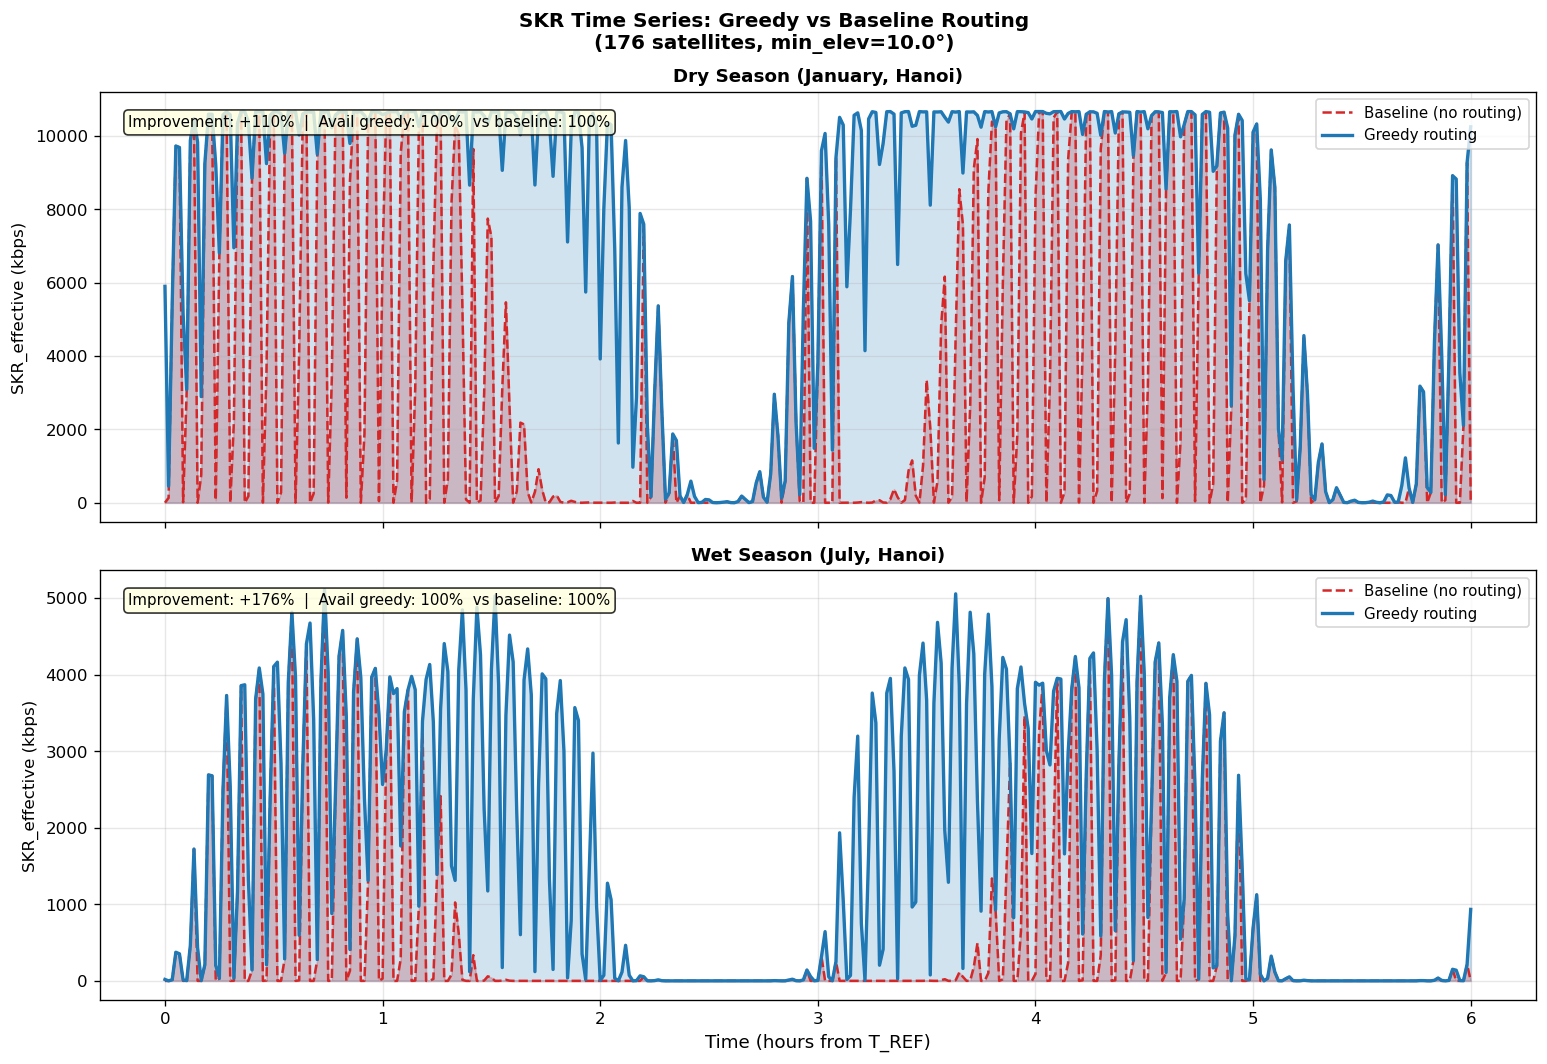

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(7.16, 5.5), sharex=True)

for ax, ts, title, c_greedy, c_base in [
    (axes[0], ts_dry, 'Dry Season (January, Hanoi)', '#1f77b4', '#d62728'),
    (axes[1], ts_wet, 'Wet Season (July, Hanoi)',    '#1f77b4', '#d62728'),
]:
    skr_g_kbps = ts['skr_greedy']   * 1e9 / 1e3
    skr_b_kbps = ts['skr_baseline'] * 1e9 / 1e3
    t = ts['time_hours']

    # Baseline first (behind), then greedy on top
    ax.fill_between(t, skr_b_kbps, alpha=0.15, color=c_base)
    ax.fill_between(t, skr_g_kbps, alpha=0.12, color=c_greedy)
    ax.plot(t, skr_b_kbps, color=c_base,   linewidth=1.0, linestyle='--',
            label='Baseline (no routing)')
    ax.plot(t, skr_g_kbps, color=c_greedy, linewidth=1.2, linestyle='-',
            label='Greedy routing')

    # Annotate improvement
    imp = compute_routing_improvement(ts['skr_greedy'], ts['skr_baseline'])
    ax.text(0.02, 0.92,
            f"Improvement: +{imp['improvement_pct']:.0f}%  |  "
            f"Avail greedy: {imp['availability_greedy']:.0%}  "
            f"vs baseline: {imp['availability_baseline']:.0%}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    ax.set_ylabel('SKR_effective (kbps)', fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    # Set ylim to max/0.9 for headroom
    y_max = max(skr_g_kbps.max(), skr_b_kbps.max())
    if y_max > 0:
        ax.set_ylim(0, y_max / 0.9)

axes[1].set_xlabel('Time (hours from T_REF)', fontsize=9)
plt.suptitle(f'SKR Time Series: Greedy vs Baseline Routing\n'
             f'({len(satellites)} satellites, min_elev={MIN_ELEV}°)',
             fontsize=9, fontweight='bold')
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig13_skr_timeseries_routing.png', bbox_inches='tight', dpi=300)
plt.show()

## 5. Routing Improvement Metrics

In [7]:
imp_dry = compute_routing_improvement(ts_dry['skr_greedy'], ts_dry['skr_baseline'])
imp_wet = compute_routing_improvement(ts_wet['skr_greedy'], ts_wet['skr_baseline'])

print('=== Routing Improvement — Hanoi ===')
print(f"{'Metric':<30} {'Dry (Jan)':>15} {'Wet (Jul)':>15}")
print('-' * 62)
for key in ['mean_skr_greedy', 'mean_skr_baseline', 'improvement_ratio',
            'improvement_pct', 'availability_greedy', 'availability_baseline']:
    vd = imp_dry[key]
    vw = imp_wet[key]
    if key == 'improvement_pct':
        print(f"{key:<30} {vd:>14.2f}% {vw:>14.2f}%")
    elif key in ('availability_greedy', 'availability_baseline'):
        print(f"{key:<30} {vd:>14.1%} {vw:>14.1%}")
    else:
        print(f"{key:<30} {vd:>15.4e} {vw:>15.4e}")

print(f"\nKey bits gain (dry): {imp_dry['key_bits_gain']:.2e} bits")
print(f"Key bits gain (wet): {imp_wet['key_bits_gain']:.2e} bits")

=== Routing Improvement — Hanoi ===
Metric                               Dry (Jan)       Wet (Jul)
--------------------------------------------------------------
mean_skr_greedy                     7.4795e-03      1.7418e-03
mean_skr_baseline                   3.5593e-03      6.3030e-04
improvement_ratio                   2.1014e+00      2.7634e+00
improvement_pct                        110.14%         176.34%
availability_greedy                    100.0%         100.0%
availability_baseline                  100.0%         100.0%

Key bits gain (dry): 8.49e+10 bits
Key bits gain (wet): 2.41e+10 bits


## 6. Multi-City Routing Comparison

hanoi          : improvement=110.1%, avail_greedy=100.0%, max_visible=4


hcmc           : improvement=71.9%, avail_greedy=100.0%, max_visible=4


danang         : improvement=100.8%, avail_greedy=100.0%, max_visible=4


bangkok        : improvement=73.4%, avail_greedy=100.0%, max_visible=4


singapore      : improvement=83.3%, avail_greedy=85.3%, max_visible=4


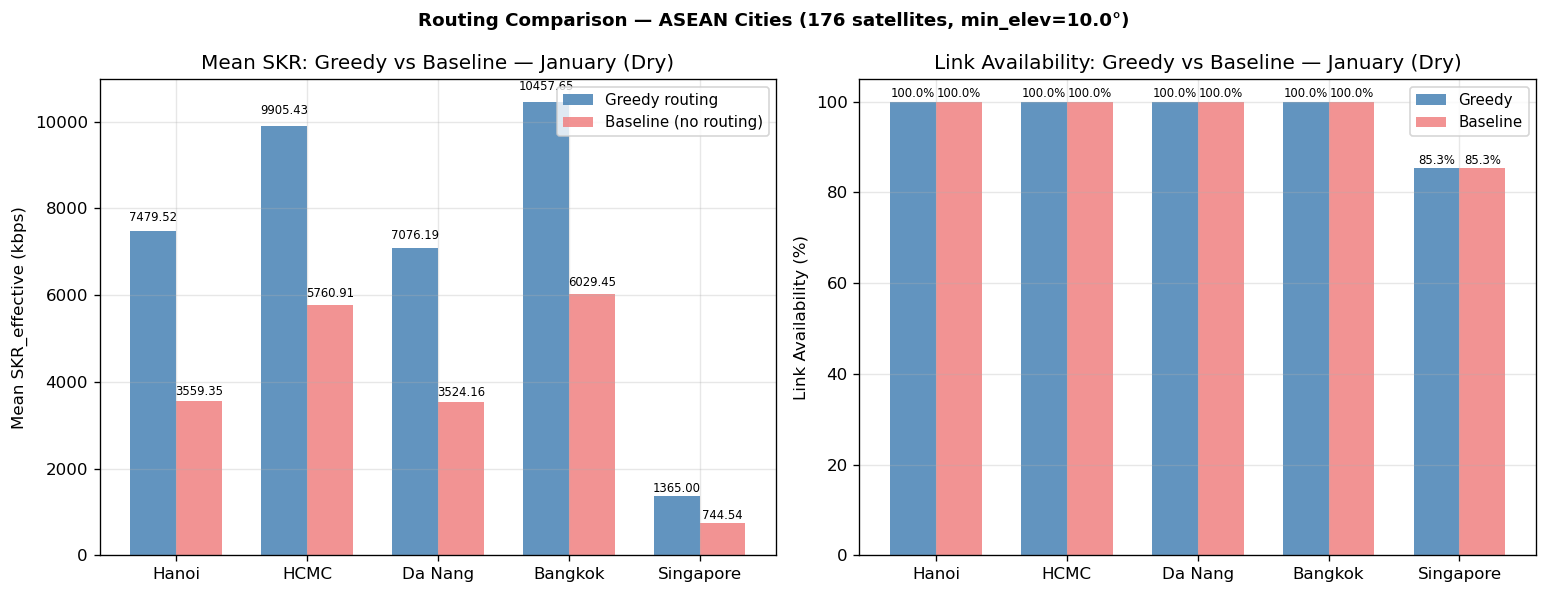

In [8]:
# Compare routing improvement across ASEAN cities (dry season, January)
cities_to_compare = ['hanoi', 'hcmc', 'danang', 'bangkok', 'singapore']
city_labels_cmp   = ['Hanoi', 'HCMC', 'Da Nang', 'Bangkok', 'Singapore']

improvement_pcts  = []
avail_greedy      = []
avail_baseline    = []
mean_skr_greedy   = []
mean_skr_baseline = []

for city in cities_to_compare:
    gs_c = GROUND_STATIONS[city]
    wx   = get_city_params(city, 1)  # January (dry for most)
    ts   = compute_skr_timeseries(
        satellites=satellites,
        lat_deg=gs_c['lat'], lon_deg=gs_c['lon'],
        t_start=T_REF,
        R_mm_h=wx['R_mm_h'], V_km=wx['V_km'], P_cloud=wx['P_cloud'],
        duration_hours=6.0, step_minutes=1.0, alt_m=gs_c['alt_m'],
        min_elevation=MIN_ELEV,
    )
    imp = compute_routing_improvement(ts['skr_greedy'], ts['skr_baseline'])
    improvement_pcts.append(imp['improvement_pct'])
    avail_greedy.append(imp['availability_greedy'])
    avail_baseline.append(imp['availability_baseline'])
    mean_skr_greedy.append(imp['mean_skr_greedy'])
    mean_skr_baseline.append(imp['mean_skr_baseline'])
    print(f"{city:15s}: improvement={imp['improvement_pct']:.1f}%, "
          f"avail_greedy={imp['availability_greedy']:.1%}, "
          f"max_visible={ts['n_visible'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5))
x = np.arange(len(cities_to_compare))
width = 0.35

# Left: Mean SKR comparison (greedy vs baseline)
skr_g_kbps = [v * 1e9 / 1e3 for v in mean_skr_greedy]
skr_b_kbps = [v * 1e9 / 1e3 for v in mean_skr_baseline]
bars1 = axes[0].bar(x - width/2, skr_g_kbps, width,
                    label='Greedy routing', color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + width/2, skr_b_kbps, width,
                    label='Baseline (no routing)', color='lightcoral', alpha=0.85)
# Value labels
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h * 1.02,
                     f'{h:.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h * 1.02,
                     f'{h:.2f}', ha='center', va='bottom', fontsize=7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(city_labels_cmp)
axes[0].set_ylabel('Mean SKR_effective (kbps)')
axes[0].set_title('Mean SKR: Greedy vs Baseline — January (Dry)')
axes[0].legend(fontsize=9)

# Right: Link availability comparison
bars3 = axes[1].bar(x - width/2, [a*100 for a in avail_greedy],   width,
                    label='Greedy',   color='steelblue', alpha=0.85)
bars4 = axes[1].bar(x + width/2, [a*100 for a in avail_baseline], width,
                    label='Baseline', color='lightcoral', alpha=0.85)
for bar in bars3:
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                     f'{h:.1f}%', ha='center', va='bottom', fontsize=7)
for bar in bars4:
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                     f'{h:.1f}%', ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(city_labels_cmp)
axes[1].set_ylabel('Link Availability (%)')
axes[1].set_title('Link Availability: Greedy vs Baseline — January (Dry)')
axes[1].legend(fontsize=9)

plt.suptitle(f'Routing Comparison — ASEAN Cities ({len(satellites)} satellites, min_elev={MIN_ELEV}°)',
             fontsize=9, fontweight='bold')
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig14_routing_comparison_cities.png', bbox_inches='tight', dpi=300)
plt.show()

## 7. Coverage Grid — ASEAN Region

Coverage fraction: 95.8%
Grid shape: (26, 36)


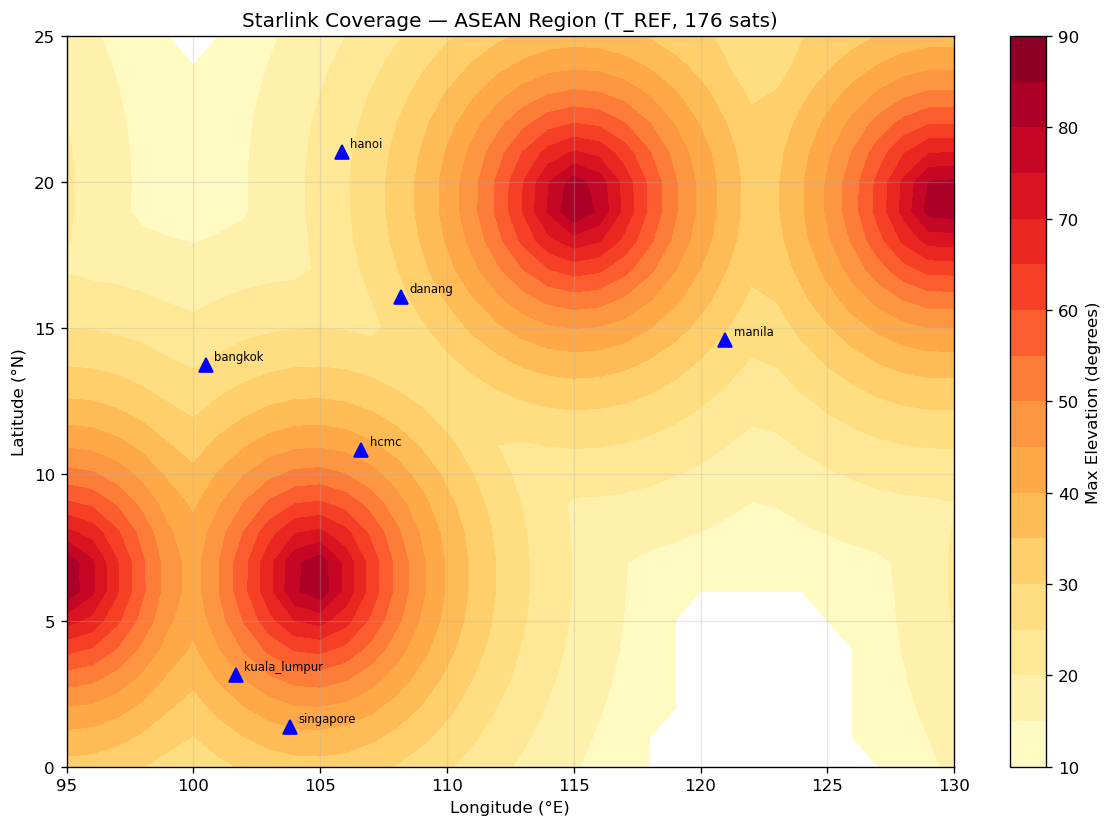

In [9]:
t_snap = _TS.from_datetime(T_REF)

grid = compute_coverage_grid(
    satellites=satellites,
    t=t_snap,
    lat_range=(0, 25),
    lon_range=(95, 130),
    resolution_deg=1.0,
    min_elevation=MIN_ELEV,
)

print(f"Coverage fraction: {grid['coverage_frac']:.1%}")
print(f"Grid shape: {grid['max_elevation'].shape}")

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(7.16, 5.5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':', color='gray')
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='#e6f2ff', zorder=0)
im = ax.contourf(
    grid['lons'], grid['lats'],
    np.where(grid['has_coverage'], grid['max_elevation'], np.nan),
    levels=np.linspace(10, 90, 17), cmap='YlOrRd', extend='neither',
    transform=ccrs.PlateCarree()
)
cbar = plt.colorbar(im, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label('Max Elevation (degrees)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

for city, gs_info in GROUND_STATIONS.items():
    ax.plot(gs_info['lon'], gs_info['lat'], 'b^', markersize=6, transform=ccrs.PlateCarree())
    ax.annotate(city, (gs_info['lon'], gs_info['lat']),
                textcoords='offset points', xytext=(4, 2), fontsize=6,
                transform=ccrs.PlateCarree())

# Draw Hoang Sa / Truong Sa
draw_vietnam_islands(ax, use_cartopy=True)

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(f'Starlink Coverage — ASEAN Region ({len(satellites)} sats)', fontsize=9)
ax.set_extent([95, 130, 0, 25], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig15_coverage_map_asean.png', bbox_inches='tight', dpi=300)
plt.show()
